(sec:nlo)=
# Multi-photon interactions

Multi-photon interactions describe the nonlinear responses of a molecular system to the simultaneous absorption or emission of two or more photons. These processes arise from higher‑order terms in the light–matter interaction and are governed by electronic transition pathways that do not appear in linear spectroscopy. Within the Born–Oppenheimer and electric‑dipole approximations, multi-photon effects are characterized by frequency‑dependent response functions—such as second‑ and third‑order polarizabilities—that encode resonant enhancements and selection rules beyond those of one‑photon transitions.

VeloxChem provides efficient tools for computing these nonlinear response properties at the levels of time‑dependent density functional theory (TDDFT) and the complex polarization propagator (CPP) aproach. By solving perturbation‑dependent response equations for multiple field frequencies, the program enables the evaluation of two‑photon absorption amplitudes, hyperpolarizabilities, and other nonlinear optical indicators relevant to multi-photon spectroscopies.

(sec:tpa)=
## Two-photon absorption

### TPA strengths

In the quadratic response theory framework, two‑photon absorption (TPA) spectra are determined from residues of the second‑order response function at half the excitation energy. TPA strengths factorize into products of transition moments, which quantify the effective coupling of the ground state to an excited state via the simultaneous interaction with two photons. The two-photon transition moment is given by the sum-over-states expression

$$
S^{f\leftarrow 0}_{\alpha\beta} = \frac{1}{\hbar}
\sum_{n} 
\Bigg[
    \frac{ 
         \langle 0 | \hat{\mu}_\alpha| n \rangle
         \langle n |\hat{\mu}_\beta | f \rangle  
         }{
         \omega_{n0}-\omega_{f0}/2
         } 
    +
    \frac{
        \langle 0 | \hat{\mu}_\beta| n \rangle 
        \langle n |\hat{\mu}_\alpha | f \rangle
        }{
        \omega_{n0}-\omega_{f0}/2
        }
    \Bigg]
$$

where $\hbar \omega_{n0}$  is the excitation energy for state $|n\rangle$, $\hat{\mu}_\alpha$ is the electric dipole moment operator along the Cartesian axis $\alpha$ , and the summation includes the ground state, $| n \rangle = | 0 \rangle$.

For an isotropic sample, the experimentally relevant TPA strengths are obtained from the orientational average of the squared magnitudes of the Cartesian transition moments. This averaging yields a scalar measure that captures the laser field polarization, and it provides the quantity directly comparable to measured TPA cross sections, see {cite}`Norman2018` for further details.

$$
\delta_f^\mathrm{TPA} = 
\frac{1}{15}
\sum_{\alpha, \beta}
\left(
2 S^{f\leftarrow 0}_{\alpha\beta} \big[S^{f\leftarrow 0}_{\alpha\beta}\big]^* +
S^{f\leftarrow 0}_{\alpha\alpha} \big[S^{f\leftarrow 0}_{\beta\beta}\big]^*
\right)
$$

We have here assumed an experimental single-beam, monochromatic, setup with linear polarization.

The TPA strength for a given state $|f\rangle$ contributes to the spectrum observable cross section, $\sigma(\omega)$, according to

$$
\sigma(\omega) = 
\frac{4 \pi^3 \alpha a_0^5 \omega^2}{c} 
\; \delta_f^\mathrm{TPA}
\; g(2\omega, \omega_{f0}, \gamma)
$$

where $\alpha$ is the fine structure constant, $a_0$ is the Bohr radius, $c$ is the speed of light, and $g$ is a line broadening function centered at half the transition angular frequency $\omega_{f0}/2$ and dependent on the dampening parameter $\gamma$.

The unit of the cross section will be GM (after [Maria Göppert-Mayer](https://sv.wikipedia.org/wiki/Maria_Goeppert-Mayer)) given that atomic units is used for $\omega$, $\delta_f^\mathrm{TPA}$, and $g$ and SI units is used for the rest, and that a multiplication by a factor of $10^{58}$ is made to account for the fact that 1 GM corresponds to $10^{-50}$ cm$^4$s photon$^{-1}$.

TPA simulations are sensitive toward the choice of basis set and exchange-correlation functional. The inclusion of diffuse functions in the basis set is typically required, and in regard with functionals, it has been demonstrated that the range-separated hybrid CAM-B3LYP and the hybrid meta-GGA MN15 functionals are good choices, see {cite}`ahmadzadeh_2024`.

**Python script**

In [28]:
import veloxchem as vlx

molecule = vlx.Molecule.read_name("para-nitroaniline")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "cam-b3lyp"
scf_results = scf_drv.compute(molecule, basis)

tpa_drv = vlx.TpaTransitionDriver()

tpa_drv.nstates = 3

tpa_results = tpa_drv.compute(molecule, basis, scf_results)

Reading para-nitroaniline from PubChem...

Reference: S. Kim, J. Chen, T. Cheng, A. Gindulyte, J. He, S. He, Q. Li, B. A. Shoemaker, P. A. Thiessen, B. Yu, L. Zaslavsky, J. Zhang, E. E. Bolton, Nucleic Acids Res., 2025, 53, D1516-D1525.

Please double-check the compound since names may refer to more than one record.

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Dir

In [30]:
photon_energies = tpa_results["photon_energies"]
delta_tpa_values = tpa_results["tpa_strengths"]["linear"]

print("State   Photon energy   TPA strength")
print(38 * "=")

idx = 0
for key, delta_tpa in delta_tpa_values.items():
    print(f"{idx+1:>3} {photon_energies[idx] * 27.2114:12.4f} eV {delta_tpa:12.2f} a.u.")
    idx += 1

State   Photon energy   TPA strength
  1       1.4728 eV         0.01 a.u.
  2       1.9233 eV         0.10 a.u.
  3       2.0913 eV      2011.76 a.u.


In [32]:
# conversion factors
au2ev = vlx.hartree_in_ev()
alpha = vlx.fine_structure_constant()
a0 = vlx.bohr_in_angstrom() * 1.0e-8
c = vlx.veloxchemlib.speed_of_light_in_vacuum_in_SI() * 100.0
au2gm = (4.0 * np.pi**2 * alpha * a0**5) / c * 1.0e+50  # NOT including the broadening parameter

In [44]:
# retrieve TPA transition results
# note that tpa_trans_results['tpa_strengths']['linear'] is a dictionary and we want tpa_trans_str as a list

tpa_trans_results = tpa_results

tpa_trans_str = [
    tpa_trans_results['tpa_strengths']['linear'][s]
    for s in tpa_trans_results['tpa_strengths']['linear']
]
tpa_trans_ene_au = tpa_trans_results['photon_energies']
tpa_trans_ene_ev = [e * au2ev for e in tpa_trans_ene_au]

# broadening of TPA strengths from TPA transition driver
# using Lorentzian profile and broadening parameter of 0.123984 eV

x_i = np.arange(0.03, 0.15, 0.0001) 
y_i = np.zeros_like(x_i)
broad = 4.556335e-03
for i in range(x_i.size):
    for s in range(len(tpa_trans_str)):
        y_i[i] += au2gm * broad / ((2 * tpa_trans_ene_au[s] - 2 * x_i[i])**2 + broad**2) * (tpa_trans_str[s] * x_i[i]**2)
x_i *= au2ev

broadened_tpa_trans_ene_ev = x_i
broadened_tpa_trans_in_gm = y_i

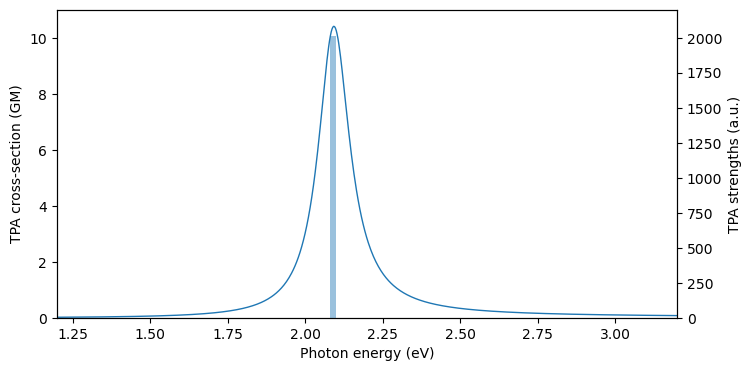

In [48]:
# plot figure
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.set_xlim(1.2, 3.2)
ax1.set_xlabel('Photon energy (eV)')
ax2 = ax1.twinx()

ax1.set_ylim(0, 11)
ax1.set_ylabel('TPA cross-section (GM)')
#ax1.plot(tpa_ene_ev, tpa_in_gm, linestyle='none', marker='o', markersize=5, markerfacecolor='none')
ax1.plot(broadened_tpa_trans_ene_ev, broadened_tpa_trans_in_gm, linewidth=1)

ax2.set_ylim(0, 2200)
ax2.set_ylabel('TPA strengths (a.u.)')
ax2.bar(tpa_trans_ene_ev, tpa_trans_str, width=0.02, alpha=0.45)

plt.show()

In [29]:
molecule.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Text file**

:::{code}
@jobs
task: response
@end

@method settings
xcfun: MN15
basis: def2-svpd
@end

@response
property: tpa transition
nstates: 10
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
@end
:::

### TPA cross section

test

In [ ]:
import veloxchem as vlx
import numpy as np

molecule = vlx.Molecule.read_name("para-nitroaniline")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "cam-b3lyp"
scf_results = scf_drv.compute(molecule, basis)

tpa_drv = vlx.TpaReducedDriver()

tpa_drv.frequencies = np.arange(0.06, 0.09, 0.0025) 

tpa_results = tpa_drv.compute(molecule, basis, scf_results)

In [27]:
tpa_results["gamma"]

{(np.float64(0.13),
  np.float64(-0.13),
  np.float64(0.13)): np.complex128(1566.821741620282+121.6344181054072j),
 (np.float64(0.135),
  np.float64(-0.135),
  np.float64(0.135)): np.complex128(1907.9084878707358+266.5020755623876j),
 (np.float64(0.14),
  np.float64(-0.14),
  np.float64(0.14)): np.complex128(1887.5875725556184+1319.5874713469786j),
 (np.float64(0.145),
  np.float64(-0.145),
  np.float64(0.145)): np.complex128(1367.8632609937233+377.49232944974085j),
 (np.float64(0.15),
  np.float64(-0.15),
  np.float64(0.15)): np.complex128(1893.021599524467+229.2720975234244j),
 (np.float64(0.155),
  np.float64(-0.155),
  np.float64(0.155)): np.complex128(2394.65007053521+254.86174443178945j),
 (np.float64(0.16),
  np.float64(-0.16),
  np.float64(0.16)): np.complex128(3036.1417507429874+363.25491518256274j),
 (np.float64(0.165),
  np.float64(-0.165),
  np.float64(0.165)): np.complex128(4042.6564211863715+663.0802175466052j),
 (np.float64(0.16999999999999998),
  np.float64(-0.169999999

:::{code}
@jobs
task: response
@end

@method settings
xcfun: MN15
basis: def2-svpd
@end

@response
property: tpa
frequencies: 0.3-0.5 (0.1)
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
@end
:::